# Vega 7a Full Public Goldset – Both Routes (subset-style report)
Same figures as `report_subset.ipynb`, but **one split**: full `7a_dicty_gold_llm_public` from `output/dicty_gold_build/7a_dicty_gold_llm_public.jsonl`.
Input workflow: `output/workflow_vega_7a_public_goldset_both_routes/{retrieval/bm25,retrieval/dense,retrieval/fusion,rerank/...,snippet/...}` (see `scripts/public/shared_scripts/docs/output.md`).

## 1. Imports and Setup

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

## 2. Load Data

In [2]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent

print("Base dir:", base_dir)

workflow_dir = base_dir / "output" / "workflow_vega_7a_public_goldset_both_routes"
retrieval_dir = workflow_dir / "retrieval"
rerank_dir = workflow_dir / "rerank"
snippet_dir = workflow_dir / "snippet"

bm25_metrics = pd.read_csv(retrieval_dir / "bm25" / "metrics.csv")
dense_metrics = pd.read_csv(retrieval_dir / "dense" / "metrics.csv")
hybrid_metrics = pd.read_csv(retrieval_dir / "fusion" / "metrics.csv")

bm25_metrics = bm25_metrics.rename(columns={"batch": "split"})
dense_metrics = dense_metrics.rename(columns={"batch": "split"})

bm25_metrics["method"] = "BM25"
dense_metrics["method"] = "Dense"
hybrid_metrics["method"] = "BM25 Dense Fusion"

output_dir = workflow_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

splits = ["7a_dicty_gold_llm_public"]
split_labels = {"7a_dicty_gold_llm_public": "7a full public"}
_N_SPLIT_COLS = len(splits)

qrels_paths = {
    "7a_dicty_gold_llm_public": base_dir / "output" / "dicty_gold_build" / "7a_dicty_gold_llm_public.jsonl",
}

print("Loaded BM25:", bm25_metrics.shape)
print("Loaded Dense:", dense_metrics.shape)
print("Loaded Hybrid:", hybrid_metrics.shape)

Base dir: /Users/yun/develop/dictycite
Loaded BM25: (1, 17)
Loaded Dense: (1, 17)
Loaded Hybrid: (6, 28)


In [3]:
# Helper: extract PMID from a PubMed URL or bare ID string
def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels(path: Path) -> dict[str, set[str]]:
    """Load gold qrels from a .jsonl file (one query record per line)."""
    qrels: dict[str, set[str]] = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            pmids = {_extract_pmid(d) for d in q.get("documents", []) if _extract_pmid(d)}
            if qid and pmids:
                qrels[qid] = pmids
    return qrels


qrels_by_split = {s: _load_qrels(p) for s, p in qrels_paths.items()}
n_per_split = {s: len(q) for s, q in qrels_by_split.items()}
print("Qrels loaded:", {s: n for s, n in n_per_split.items()})

# Single-split: drop redundant axis titles; put query count on suptitle and tighten top margin.
_N_PRIMARY: int | None = int(next(iter(n_per_split.values()))) if _N_SPLIT_COLS == 1 else None
_TIGHT_RECT = [0, 0, 1, 0.93] if _N_SPLIT_COLS <= 1 else [0, 0, 1, 0.96]


def _suptitle_n(title: str) -> str:
    return f"{title} (n={_N_PRIMARY})" if _N_PRIMARY is not None else title


def _axis_split_title(ax, split: str, *, fontsize: int = 15) -> None:
    if _N_SPLIT_COLS <= 1:
        return
    n_split = n_per_split.get(split, "?")
    ax.set_title(
        f"{split_labels.get(split, split)} (n={n_split})",
        fontsize=fontsize,
        fontweight="bold",
    )

Qrels loaded: {'7a_dicty_gold_llm_public': 1656}


## 3. Stage 1 Recall Curves (one panel per configured split)

Shared K values (plotted up to 2000): [10, 50, 100, 200, 300, 400, 500, 1000, 2000]
Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/01_stage1_recall_per_split.png


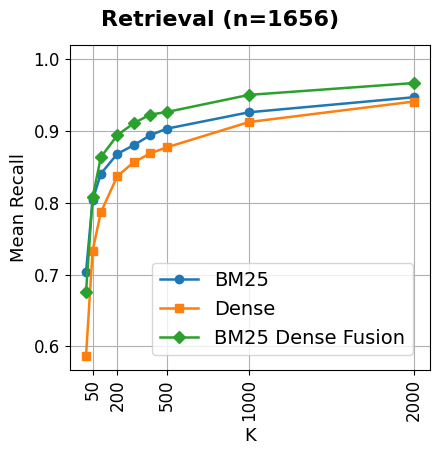

In [4]:
recall_cols_bm25 = sorted(
    [c for c in bm25_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols_hybrid = sorted(
    [c for c in hybrid_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols = sorted(
    set(recall_cols_bm25) & set(recall_cols_hybrid),
    key=lambda c: int(c.split("@")[1]),
)
recall_cols = [c for c in recall_cols if int(c.split("@")[1]) <= 2000]
k_values = [int(c.split("@")[1]) for c in recall_cols]

print("Shared K values (plotted up to 2000):", k_values)

tick_candidates = [50, 200, 500, 1000, 2000]
tick_values = [k for k in tick_candidates if k in k_values]

methods_cfg = {
    "BM25": {"df": bm25_metrics, "color": "#1f77b4", "marker": "o"},
    "Dense": {"df": dense_metrics, "color": "#ff7f0e", "marker": "s"},
    "BM25 Dense Fusion": {"df": hybrid_metrics, "color": "#2ca02c", "marker": "D"},
}

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_cfg.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
#global_ymax = min(1, global_ymax + y_pad)
global_ymax = 1.02

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, cfg in methods_cfg.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        ax.plot(
            k_values,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    _axis_split_title(ax, split)
    ax.set_ylim(global_ymin, global_ymax)

    if idx == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("K")
    ax.set_xticks(tick_values)
    ax.set_xticklabels([str(k) for k in tick_values], rotation=90)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.95, 0.19), fontsize=14)

fig.suptitle(_suptitle_n("Retrieval"), fontsize=16, fontweight="bold", y=0.9)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "01_stage1_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 4. Retrieval vs Rerank – Recall Curves (K ≤ 300)

Stage2+ K values (≤300): [10, 50, 100, 200, 300]
Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/02_hybrid_rerank_fusion_recall_per_split.png


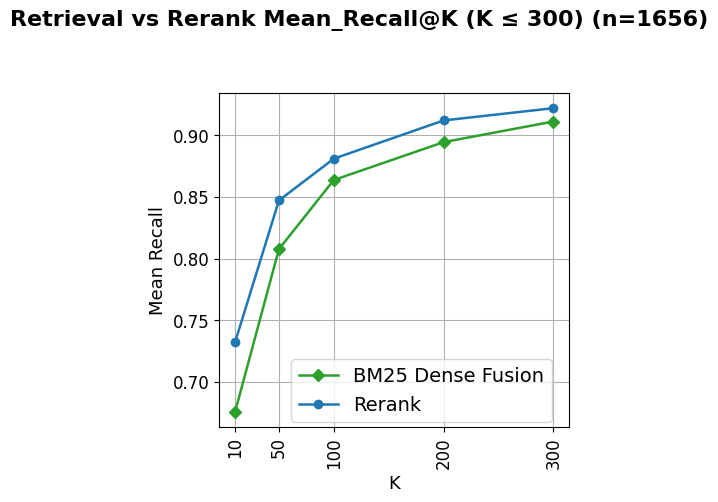

In [5]:
hybrid_stage1 = hybrid_metrics.copy()
rerank_metrics = pd.read_csv(rerank_dir / "cross_encoder" / "metrics.csv")
rerank_fusion_metrics = pd.read_csv(rerank_dir / "post_rerank_fusion_snippet" / "metrics.csv")

if "split" not in rerank_metrics.columns:
    if "label" in rerank_metrics.columns:
        rerank_metrics = rerank_metrics.rename(columns={"label": "split"})
    elif "batch" in rerank_metrics.columns:
        rerank_metrics = rerank_metrics.rename(columns={"batch": "split"})
if "split" not in rerank_fusion_metrics.columns and "batch" in rerank_fusion_metrics.columns:
    rerank_fusion_metrics = rerank_fusion_metrics.rename(columns={"batch": "split"})

methods_stage2 = {
    "BM25 Dense Fusion": {
        "df": hybrid_stage1,
        "color": "#2ca02c",
        "marker": "D",
    },
    "Rerank": {
        "df": rerank_metrics,
        "color": "#1f77b4",
        "marker": "o",
    },
}

recall_cols_all = []
for cfg in methods_stage2.values():
    cols = [c for c in cfg["df"].columns if c.startswith("MeanR@")]
    recall_cols_all.append(set(cols))

recall_cols_common = sorted(
    set.intersection(*recall_cols_all),
    key=lambda c: int(c.split("@")[1]),
)
k_vals_recall = [int(c.split("@")[1]) for c in recall_cols_common if 10 <= int(c.split("@")[1]) <= 300]
recall_cols_common = [f"MeanR@{k}" for k in k_vals_recall]

print("Stage2+ K values (≤300):", k_vals_recall)

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_stage2.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
global_ymax = min(1, global_ymax + y_pad)

tick_candidates_recall = [10, 50, 100, 200, 300]
tick_values_recall = [k for k in tick_candidates_recall if k in k_vals_recall]

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, cfg in methods_stage2.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        ax.plot(
            k_vals_recall,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    _axis_split_title(ax, split)
    ax.set_ylim(global_ymin, global_ymax)

    if idx == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("K")
    ax.set_xticks(tick_values_recall)
    ax.set_xticklabels([str(k) for k in tick_values_recall], rotation=90)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=14)

fig.suptitle(_suptitle_n("Retrieval vs Rerank Mean_Recall@K (K ≤ 300)"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "02_hybrid_rerank_fusion_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 5. Retrieval vs Rerank vs Post-rerank Fusion – MAP@10 (Bar Plots)

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/03_hybrid_rerank_fusion_map10_bars_per_split.png


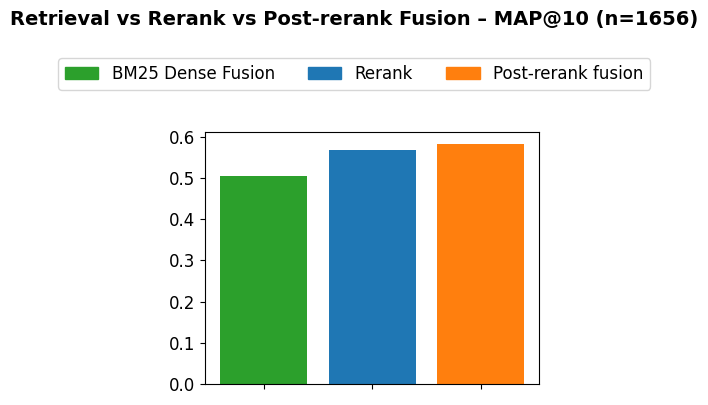

In [6]:
fig, axes_bar = plt.subplots(1, _N_SPLIT_COLS, figsize=(4 * _N_SPLIT_COLS, 4), sharey=True, squeeze=False)
axes_bar = axes_bar.ravel()

method_colors_bar = {
    "BM25 Dense Fusion": "#2ca02c",
    "Rerank": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

for idx, split in enumerate(splits):
    cur_ax = axes_bar[idx]
    vals = []
    labels_methods = []

    row_h = hybrid_stage1[hybrid_stage1["split"] == split]
    if not row_h.empty:
        vals.append(float(row_h.iloc[0]["MAP@10"]))
        labels_methods.append("BM25 Dense Fusion")

    row_r = rerank_metrics[rerank_metrics["split"] == split]
    if not row_r.empty:
        vals.append(float(row_r.iloc[0]["MAP@10"]))
        labels_methods.append("Rerank")

    row_f = rerank_fusion_metrics[rerank_fusion_metrics["split"] == split]
    if not row_f.empty:
        vals.append(float(row_f.iloc[0]["MAP@10"]))
        labels_methods.append("Post-rerank fusion")

    x = np.arange(len(labels_methods))
    colors = [method_colors_bar[label] for label in labels_methods]
    cur_ax.bar(x, vals, color=colors)
    cur_ax.set_xticks(x)
    cur_ax.set_xticklabels("", rotation=30, ha="right")
    _axis_split_title(cur_ax, split, fontsize=13)

handles_bar = [
    plt.matplotlib.patches.Patch(color=method_colors_bar[m], label=m)
    for m in method_colors_bar
]
fig.suptitle(
    _suptitle_n("Retrieval vs Rerank vs Post-rerank Fusion – MAP@10"),
    fontsize=14,
    fontweight="bold",
    y=1.0,
)
fig.legend(handles=handles_bar, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.90), fontsize=12)

_bar_rect = [0, 0, 1, 0.82] if _N_SPLIT_COLS <= 1 else [0, 0, 1, 0.9]
plt.tight_layout(rect=_bar_rect)
fig_path = output_dir / "03_hybrid_rerank_fusion_map10_bars_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 6. Retrieval vs Rerank vs Post-rerank Fusion – MAP@K Curves

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04_hybrid_rerank_fusion_mapk_per_split.png


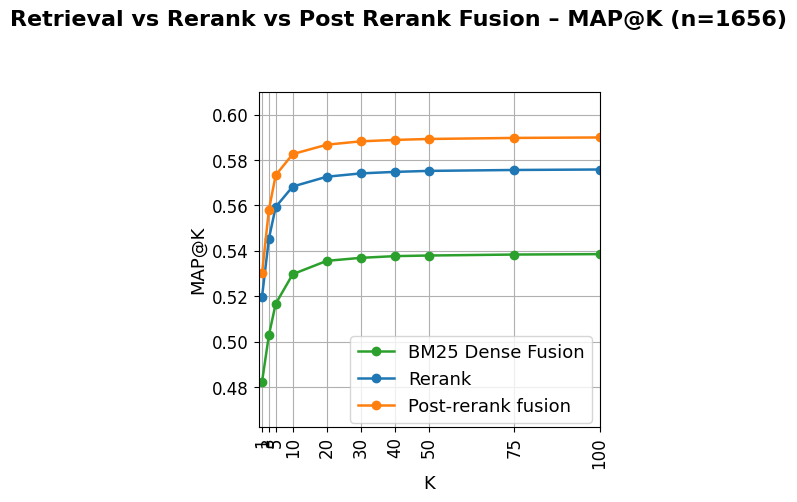

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04b_hybrid_rerank_fusion_mrrk_per_split.png


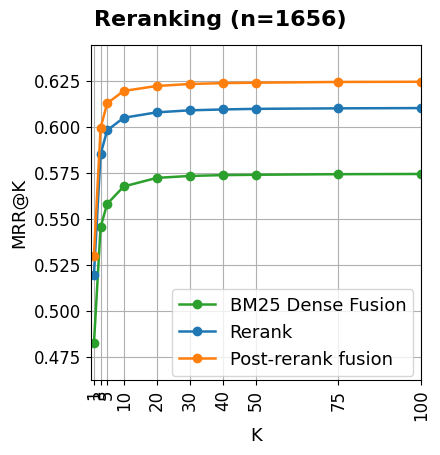

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04_hybrid_rerank_mapk_per_split_no_post_fusion.png


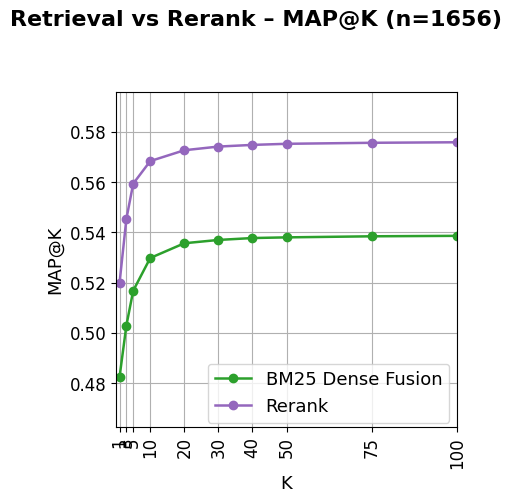

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04c_hybrid_rerank_mrrk_per_split_no_post_fusion.png


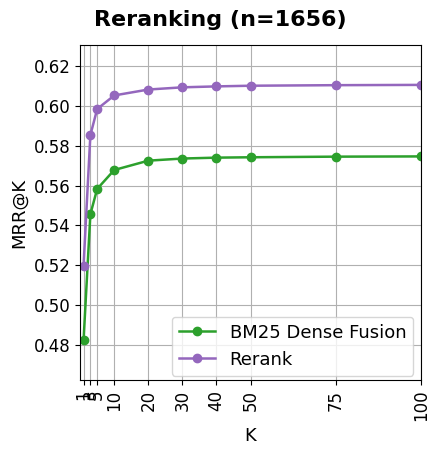

In [7]:
map_ks = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]


def _load_run(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _ap_at_k(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    denom = min(len(rels), k)
    if denom == 0:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            hits += 1
            score += hits / i
    return score / denom


def _mrr_at_k(docs: list[str], rels: set[str], k: int) -> float:
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            return 1.0 / i
    return 0.0


def _recall_at_k(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    hits = sum(1 for d in docs[:k] if d in rels)
    return hits / len(rels)


def _map_at_ks_for_run(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_ap_at_k(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}


def _mrr_at_ks_for_run(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_mrr_at_k(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}

run_dirs = {
    "BM25 Dense Fusion": retrieval_dir / "fusion" / "runs",
    "Rerank": rerank_dir / "cross_encoder" / "runs",
    "Post-rerank fusion": rerank_dir / "post_rerank_fusion_snippet" / "runs",
}

map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)
mrr_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits:
    qrels_split = qrels_by_split.get(split, {})
    for method_name, runs_dir in run_dirs.items():
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        map_curves[method_name][split] = _map_at_ks_for_run(run_df, qrels_split, map_ks)
        mrr_curves[method_name][split] = _mrr_at_ks_for_run(run_df, qrels_split, map_ks)

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

all_maps = []
for method_dict in map_curves.values():
    for split_vals in method_dict.values():
        all_maps.extend(split_vals.values())

if all_maps:
    y_min = max(0.0, min(all_maps) - 0.02)
    y_max = min(1.0, max(all_maps) + 0.02)
else:
    y_min, y_max = 0.0, 1.0

colors_map = {
    "BM25 Dense Fusion": "#2ca02c",
    "Rerank": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, method_dict in map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            vals,
            marker="o",
            color=colors_map.get(method_name),
            label=method_name,
            linewidth=1.8,
        )
    _axis_split_title(ax, split)
    ax.set_ylim(y_min, y_max)

    if idx == 0:
        ax.set_ylabel("MAP@K")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)

fig.suptitle(_suptitle_n("Retrieval vs Rerank vs Post Rerank Fusion – MAP@K"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "04_hybrid_rerank_fusion_mapk_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

# --- MRR@K version (mirrors MAP@K figure above) ---
all_mrrs = [v for md in mrr_curves.values() for sv in md.values() for v in sv.values()]
if all_mrrs:
    y_min_mrr = max(0.0, min(all_mrrs) - 0.02)
    y_max_mrr = min(1.0, max(all_mrrs) + 0.02)
else:
    y_min_mrr, y_max_mrr = 0.0, 1.0

fig_mrr, axes_mrr = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes_mrr = axes_mrr.ravel()
for idx, split in enumerate(splits):
    ax = axes_mrr[idx]
    for method_name, method_dict in mrr_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(map_ks, vals, marker="o", color=colors_map.get(method_name), label=method_name, linewidth=1.8)
    _axis_split_title(ax, split)
    ax.set_ylim(y_min_mrr, y_max_mrr)
    ax.set_ylabel("MRR@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
handles_mrr, labels_mrr = axes_mrr[0].get_legend_handles_labels()
fig_mrr.legend(handles_mrr, labels_mrr, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)
fig_mrr.suptitle(_suptitle_n("Reranking"), fontsize=16, fontweight="bold", y=0.9)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_mrr = output_dir / "04b_hybrid_rerank_fusion_mrrk_per_split.png"
plt.savefig(fig_path_mrr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_mrr)
plt.show()

# Same MAP@K curves without post-rerank fusion (clearer when fusion overlaps / dominates).
map_curves_rr = {k: v for k, v in map_curves.items() if k != "Post-rerank fusion"}
mrr_curves_rr = {k: v for k, v in mrr_curves.items() if k != "Post-rerank fusion"}
colors_map_rr = {
    "BM25 Dense Fusion": colors_map["BM25 Dense Fusion"],
    "Rerank": "#9467bd",
}
all_maps_rr = []
for method_dict in map_curves_rr.values():
    for split_vals in method_dict.values():
        all_maps_rr.extend(split_vals.values())

if all_maps_rr:
    y_min_rr = max(0.0, min(all_maps_rr) - 0.02)
    y_max_rr = min(1.0, max(all_maps_rr) + 0.02)
else:
    y_min_rr, y_max_rr = 0.0, 1.0

fig2, axes2 = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes2 = axes2.ravel()
for idx, split in enumerate(splits):
    ax = axes2[idx]
    for method_name, method_dict in map_curves_rr.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(map_ks, vals, marker="o", color=colors_map_rr.get(method_name), label=method_name, linewidth=1.8)
    _axis_split_title(ax, split)
    ax.set_ylim(y_min_rr, y_max_rr)
    ax.set_ylabel("MAP@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles2, labels2 = axes2[0].get_legend_handles_labels()
fig2.legend(handles2, labels2, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)
fig2.suptitle(_suptitle_n("Retrieval vs Rerank – MAP@K"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_rr = output_dir / "04_hybrid_rerank_mapk_per_split_no_post_fusion.png"
plt.savefig(fig_path_rr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_rr)
plt.show()

# --- MRR@K no-fusion version ---
all_mrrs_rr = [v for md in mrr_curves_rr.values() for sv in md.values() for v in sv.values()]
if all_mrrs_rr:
    y_min_mrr_rr = max(0.0, min(all_mrrs_rr) - 0.02)
    y_max_mrr_rr = min(1.0, max(all_mrrs_rr) + 0.02)
else:
    y_min_mrr_rr, y_max_mrr_rr = 0.0, 1.0

fig2_mrr, axes2_mrr = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes2_mrr = axes2_mrr.ravel()
for idx, split in enumerate(splits):
    ax = axes2_mrr[idx]
    for method_name, method_dict in mrr_curves_rr.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(map_ks, vals, marker="o", color=colors_map_rr.get(method_name), label=method_name, linewidth=1.8)
    _axis_split_title(ax, split)
    ax.set_ylim(y_min_mrr_rr, y_max_mrr_rr)
    ax.set_ylabel("MRR@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
handles2_mrr, labels2_mrr = axes2_mrr[0].get_legend_handles_labels()
fig2_mrr.legend(handles2_mrr, labels2_mrr, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)
fig2_mrr.suptitle(_suptitle_n("Reranking"), fontsize=16, fontweight="bold", y=0.9)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_mrr_rr = output_dir / "04c_hybrid_rerank_mrrk_per_split_no_post_fusion.png"
plt.savefig(fig_path_mrr_rr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_mrr_rr)
plt.show()

## 7. Gold Count Histogram per Query (7a full public)

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/05_gold_count_hist_all.png


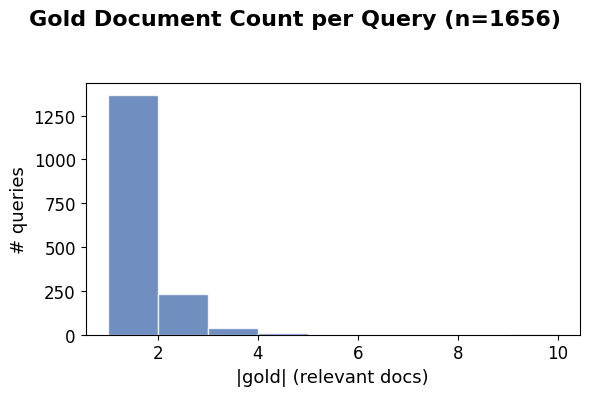

In [8]:
gold_split = splits[0]

gold_counts_all = [len(v) for v in qrels_by_split[gold_split].values()]

max_gold = max(gold_counts_all) if gold_counts_all else 0
bins = range(1, max_gold + 2) if max_gold > 0 else [0, 1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gold_counts_all, bins=bins, color="#4c72b0", alpha=0.8, edgecolor="white")
ax.set_xlabel("|gold| (relevant docs)")
ax.set_ylabel("# queries")

fig.suptitle(_suptitle_n("Gold Document Count per Query"), fontsize=16, fontweight="bold", y=0.98)
_hist_rect = [0, 0, 1, 0.92] if _N_SPLIT_COLS <= 1 else [0, 0, 1, 1.0]
plt.tight_layout(rect=_hist_rect)
fig_path = output_dir / "05_gold_count_hist_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 8. MAP@K Stratified by Gold Count (7a; |gold| = 1, >1)

Per-query AP@K rows: 49680
Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/06_mapk_by_gold_bucket_all.png


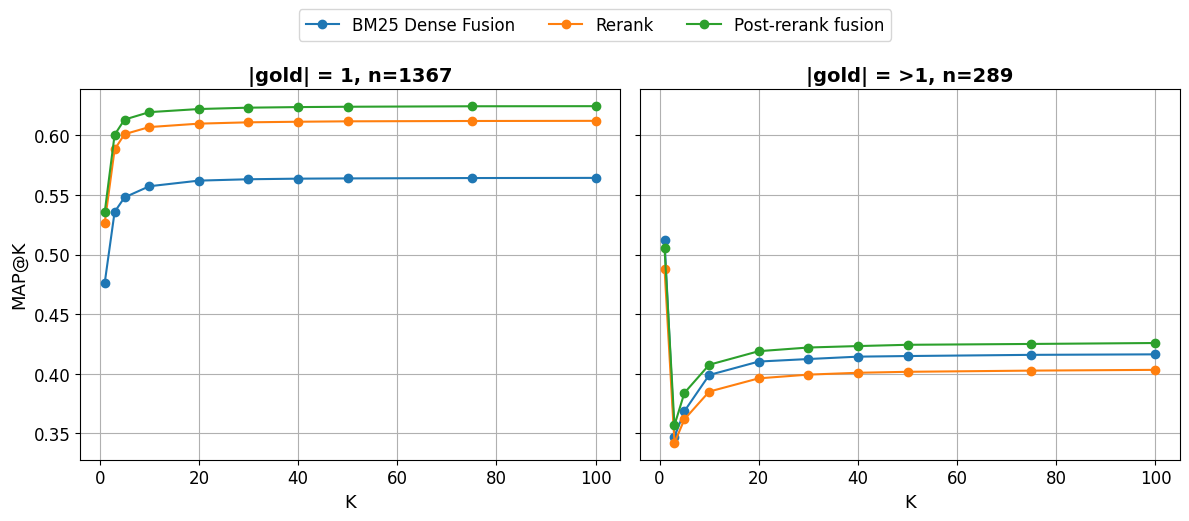

In [9]:
bucket_order = ["1", ">1"]


def _gold_bucket(n: int) -> str:
    if n == 1:
        return "1"
    return ">1"


records = []
for method_name, runs_dir in run_dirs.items():
    for split in splits:
        qrels_split = qrels_by_split[split]
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)

        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels_split.get(str(qid))
            if not rels:
                continue
            gold_n = len(rels)
            bucket = _gold_bucket(gold_n)
            docs = group[doc_col].tolist()
            for k in map_ks:
                ap = _ap_at_k(docs, set(rels), k)
                records.append(
                    {
                        "split": split,
                        "method": method_name,
                        "qid": str(qid),
                        "gold_n": gold_n,
                        "bucket": bucket,
                        "k": k,
                        "AP@K": ap,
                    }
                )

map_pq_df = pd.DataFrame(records)
print("Per-query AP@K rows:", len(map_pq_df))

summary = (
    map_pq_df.groupby(["method", "bucket", "k"], as_index=False)["AP@K"]
    .mean()
    .rename(columns={"AP@K": "MAP@K"})
)

bucket_counts = (
    map_pq_df[["qid", "bucket"]]
    .drop_duplicates()
    .groupby("bucket")["qid"]
    .nunique()
    .to_dict()
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

for idx, bucket in enumerate(bucket_order):
    ax = axes[idx]
    bucket_df = summary[summary["bucket"] == bucket]
    if bucket_df.empty:
        ax.set_visible(False)
        continue
    for method_name in run_dirs.keys():
        m_df = bucket_df[bucket_df["method"] == method_name]
        if m_df.empty:
            continue
        ax.plot(
            m_df["k"],
            m_df["MAP@K"],
            marker="o",
            label=method_name,
        )
    n_bucket = bucket_counts.get(bucket, 0)
    ax.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx == 0:
        ax.set_ylabel("MAP@K")
    ax.set_xlabel("K")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(run_dirs), bbox_to_anchor=(0.5, 1.05), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "06_mapk_by_gold_bucket_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/06b_mapk_recall_by_gold_bucket_all.png


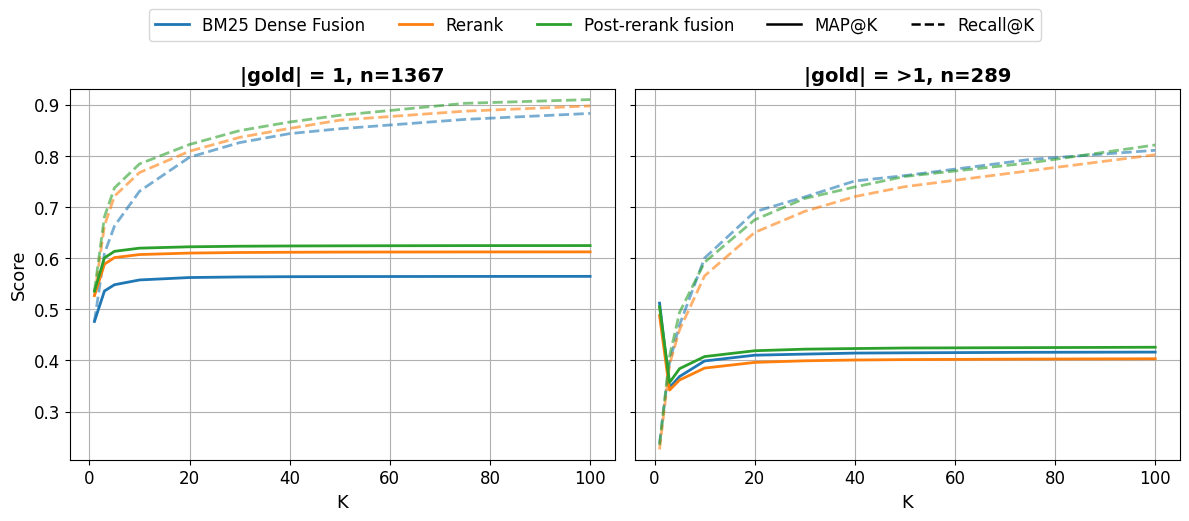

In [10]:
recall_records = []
for method_name, runs_dir in run_dirs.items():
    for split in splits:
        qrels_split = qrels_by_split[split]
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels_split.get(str(qid))
            if not rels:
                continue
            docs = group[doc_col].tolist()
            bucket = _gold_bucket(len(rels))
            for k in map_ks:
                recall_records.append({
                    "method": method_name,
                    "bucket": bucket,
                    "k": k,
                    "Recall@K": _recall_at_k(docs, set(rels), k),
                })

recall_pq_df = pd.DataFrame(recall_records)
recall_summary = (
    recall_pq_df.groupby(["method", "bucket", "k"], as_index=False)["Recall@K"]
    .mean()
)

combined = summary.merge(recall_summary, on=["method", "bucket", "k"], how="outer")

all_vals = list(combined["MAP@K"].dropna()) + list(combined["Recall@K"].dropna())
y_min_c = max(0.0, min(all_vals) - 0.02) if all_vals else 0.0
y_max_c = min(1.0, max(all_vals) + 0.02) if all_vals else 1.0

method_colors_combined = {name: f"C{i}" for i, name in enumerate(run_dirs)}

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

for idx, bucket in enumerate(bucket_order):
    ax = axes[idx]
    bucket_df = combined[combined["bucket"] == bucket]
    if bucket_df.empty:
        ax.set_visible(False)
        continue
    for method_name in run_dirs:
        m_df = bucket_df[bucket_df["method"] == method_name].sort_values("k")
        if m_df.empty:
            continue
        c = method_colors_combined[method_name]
        ax.plot(
            m_df["k"],
            m_df["MAP@K"],
            color=c,
            linewidth=2.0,
        )
        ax.plot(
            m_df["k"],
            m_df["Recall@K"],
            color=c,
            linewidth=2.0,
            linestyle="--",
            alpha=0.6,
        )
    n_bucket = bucket_counts.get(bucket, 0)
    ax.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
    ax.set_ylim(y_min_c, y_max_c)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx == 0:
        ax.set_ylabel("Score")
    ax.set_xlabel("K")

method_handles = [
    Line2D([], [], color=method_colors_combined[m], linewidth=2.0, label=m)
    for m in run_dirs
]
style_handles = [
    Line2D([], [], color="black", linewidth=1.8, linestyle="-", label="MAP@K"),
    Line2D([], [], color="black", linewidth=1.8, linestyle="--", label="Recall@K"),
]
fig.legend(
    handles=method_handles + style_handles,
    loc="upper center",
    ncol=len(run_dirs) + 2,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "06b_mapk_recall_by_gold_bucket_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 10. Snippet Rerank vs Rerank Hybrid 200 – MAP@K Curves

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/08_snippet_rerank_vs_rerank_hybrid200_mapk.png


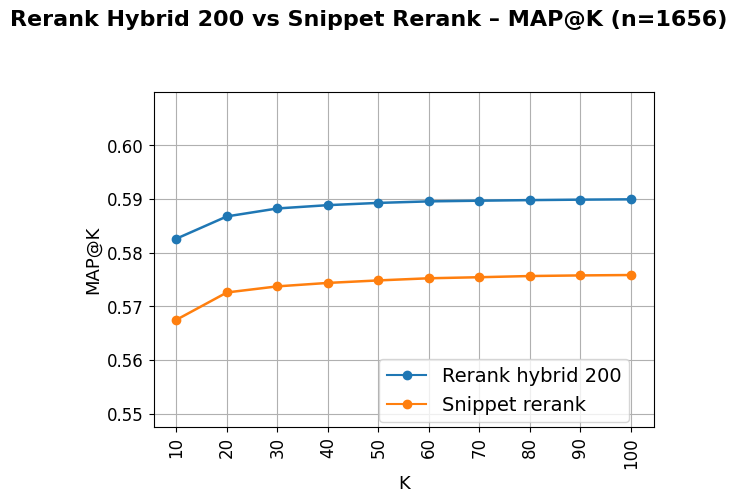

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/08b_snippet_rerank_vs_rerank_hybrid200_mrrk.png


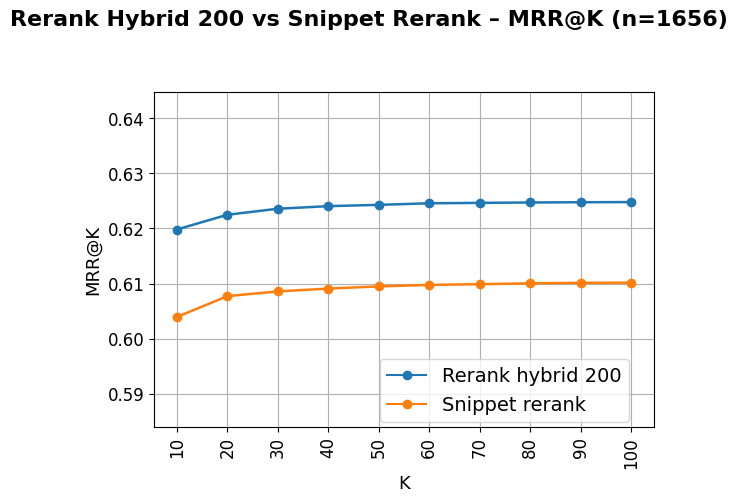

In [11]:
snippet_run_dirs = {
    "Rerank hybrid 200": rerank_dir / "post_rerank_fusion_snippet" / "runs",
    "Snippet rerank": snippet_dir / "snippet_rerank" / "runs",
}

snippet_map_ks = list(range(10, 101, 10))

snippet_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)
snippet_mrr_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    for method_name, runs_dir in snippet_run_dirs.items():
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        snippet_map_curves[method_name][split] = _map_at_ks_for_run(run_df, qrels_split, snippet_map_ks)
        snippet_mrr_curves[method_name][split] = _mrr_at_ks_for_run(run_df, qrels_split, snippet_map_ks)

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(6 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

all_vals_snippet: list[float] = []
for method_dict in snippet_map_curves.values():
    for split_vals in method_dict.values():
        all_vals_snippet.extend(split_vals.values())

if all_vals_snippet:
    y_min_s = max(0.0, min(all_vals_snippet) - 0.02)
    y_max_s = min(1.0, max(all_vals_snippet) + 0.02)
else:
    y_min_s, y_max_s = 0.0, 1.0

colors_snippet = {
    "Rerank hybrid 200": "#1f77b4",
    "Snippet rerank": "#ff7f0e",
}

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, method_dict in snippet_map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in snippet_map_ks]
        ax.plot(
            snippet_map_ks,
            vals,
            marker="o",
            linewidth=1.8,
            color=colors_snippet[method_name],
            label=method_name,
        )
    _axis_split_title(ax, split, fontsize=14)
    ax.set_ylim(y_min_s, y_max_s)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx == 0:
        ax.set_ylabel("MAP@K")
    ax.set_xlabel("K")
    ax.set_xticks(snippet_map_ks)
    ax.set_xticklabels([str(k) for k in snippet_map_ks], rotation=90)

legend_snippet_handles = [
    Line2D([0], [0], color=colors_snippet[name], marker="o", linestyle="-", label=name)
    for name in colors_snippet
]
fig.legend(
    handles=legend_snippet_handles,
    labels=list(colors_snippet),
    loc="lower right",
    bbox_to_anchor=(0.95, 0.15),
    fontsize=14,
)
fig.suptitle(
    _suptitle_n("Rerank Hybrid 200 vs Snippet Rerank – MAP@K"),
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "08_snippet_rerank_vs_rerank_hybrid200_mapk.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

# --- MRR@K version ---
all_vals_snippet_mrr = [v for md in snippet_mrr_curves.values() for sv in md.values() for v in sv.values()]
if all_vals_snippet_mrr:
    y_min_s_mrr = max(0.0, min(all_vals_snippet_mrr) - 0.02)
    y_max_s_mrr = min(1.0, max(all_vals_snippet_mrr) + 0.02)
else:
    y_min_s_mrr, y_max_s_mrr = 0.0, 1.0

fig_s_mrr, axes_s_mrr = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(6 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes_s_mrr = axes_s_mrr.ravel()
for idx, split in enumerate(splits):
    ax = axes_s_mrr[idx]
    for method_name, method_dict in snippet_mrr_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in snippet_map_ks]
        ax.plot(snippet_map_ks, vals, marker="o", linewidth=1.8, color=colors_snippet[method_name], label=method_name)
    _axis_split_title(ax, split, fontsize=14)
    ax.set_ylim(y_min_s_mrr, y_max_s_mrr)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    ax.set_ylabel("MRR@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(snippet_map_ks)
    ax.set_xticklabels([str(k) for k in snippet_map_ks], rotation=90)
legend_s_mrr = [Line2D([0], [0], color=colors_snippet[n], marker="o", label=n) for n in colors_snippet]
fig_s_mrr.legend(handles=legend_s_mrr, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=14)
fig_s_mrr.suptitle(_suptitle_n("Rerank Hybrid 200 vs Snippet Rerank – MRR@K"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_s_mrr = output_dir / "08b_snippet_rerank_vs_rerank_hybrid200_mrrk.png"
plt.savefig(fig_path_s_mrr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_s_mrr)
plt.show()

## 11. RRF Fusion Sweep: MAP@10 vs Weight (rerank_hybrid_200 + snippet_rerank)

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/09_rrf_fusion_map10_vs_weight.png


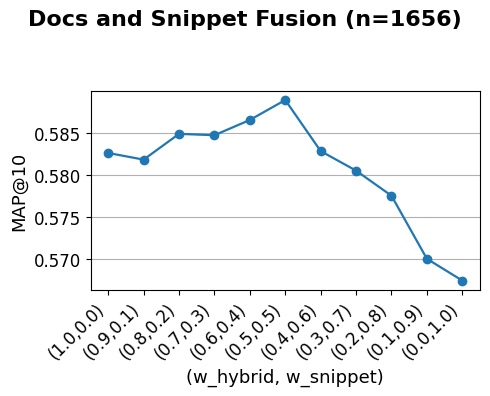

In [12]:
RUN_TOP = 100
OUTPUT_TOP = 10
RRF_KS = [60]
RRF_WEIGHTS = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0),
]


def _build_run_map(run_df: pd.DataFrame) -> dict[str, list[str]]:
    qid_col, doc_col = run_df.columns.tolist()
    run_map: dict[str, list[str]] = {}
    for qid, group in run_df.groupby(qid_col, sort=False):
        run_map[str(qid)] = group[doc_col].astype(str).tolist()
    return run_map


def _rrf_fuse_docs(
    docs_hybrid: list[str],
    docs_snippet: list[str],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
    run_top: int,
    output_top: int,
) -> list[str]:
    hybrid_top = docs_hybrid[:run_top]
    snippet_top = docs_snippet[:run_top]
    rank_h = {d: i + 1 for i, d in enumerate(hybrid_top)}
    rank_s = {d: i + 1 for i, d in enumerate(snippet_top)}
    union = list(dict.fromkeys(hybrid_top + snippet_top))
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        rh = rank_h.get(d)
        rs = rank_s.get(d)
        if rh is not None:
            s += w_hybrid / (k_rrf + rh)
        if rs is not None:
            s += w_snippet / (k_rrf + rs)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored[:output_top]]


def _ap10_for_fusion(
    gold: dict[str, set[str]],
    run_hybrid: dict[str, list[str]],
    run_snippet: dict[str, list[str]],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
) -> tuple[float, int]:
    qids = [q for q in gold if q in run_hybrid and q in run_snippet and gold[q]]
    if not qids:
        return 0.0, 0
    ap_vals: list[float] = []
    for q in qids:
        rels = set(gold[q])
        fused_docs = _rrf_fuse_docs(
            run_hybrid[q],
            run_snippet[q],
            k_rrf=k_rrf,
            w_hybrid=w_hybrid,
            w_snippet=w_snippet,
            run_top=RUN_TOP,
            output_top=OUTPUT_TOP,
        )
        ap_vals.append(_ap_at_k(fused_docs, rels, k=OUTPUT_TOP))
    return (float(np.mean(ap_vals)) if ap_vals else 0.0, len(qids))


hybrid_run_maps: dict[str, dict[str, list[str]]] = {}
snippet_run_maps_sweep: dict[str, dict[str, list[str]]] = {}

for split in splits:
    h_dir = rerank_dir / "post_rerank_fusion_snippet" / "runs"
    h_candidates = list(h_dir.glob(f"best_rrf_{split}_top5000*.tsv"))
    s_dir = snippet_dir / "snippet_rerank" / "runs"
    s_candidates = list(s_dir.glob(f"best_rrf_{split}_top5000*.tsv"))

    if not h_candidates or not s_candidates:
        continue

    df_h = _load_run(h_candidates[0])
    df_s = _load_run(s_candidates[0])

    hybrid_run_maps[split] = _build_run_map(df_h)
    snippet_run_maps_sweep[split] = _build_run_map(df_s)

rrf_rows: list[dict[str, object]] = []

for split in splits:
    gold = qrels_by_split.get(split)
    run_h = hybrid_run_maps.get(split)
    run_s = snippet_run_maps_sweep.get(split)
    if not gold or not run_h or not run_s:
        continue
    for k_rrf in RRF_KS:
        for w_h, w_s in RRF_WEIGHTS:
            map10, n_q = _ap10_for_fusion(
                gold=gold,
                run_hybrid=run_h,
                run_snippet=run_s,
                k_rrf=k_rrf,
                w_hybrid=w_h,
                w_snippet=w_s,
            )
            rrf_rows.append(
                {
                    "split": split,
                    "k_rrf": k_rrf,
                    "w_hybrid": w_h,
                    "w_snippet": w_s,
                    "MAP@10": map10,
                    "n_queries": n_q,
                }
            )

rrf_results = pd.DataFrame(rrf_rows)
if not rrf_results.empty:
    rrf_results["weight_label"] = rrf_results.apply(
        lambda r: f"({r['w_hybrid']:.1f},{r['w_snippet']:.1f})",
        axis=1,
    )

weight_order = [f"({w[0]:.1f},{w[1]:.1f})" for w in RRF_WEIGHTS]

if not rrf_results.empty:
    n_splits = rrf_results["split"].nunique()
    fig, axes = plt.subplots(1, n_splits, figsize=(5 * n_splits, 4), sharey=True)
    if n_splits == 1:
        axes = np.array([axes])
    axes_flat = list(axes.flat)

    for idx, (ax, (split, grp)) in enumerate(zip(axes_flat, rrf_results.groupby("split", sort=False))):
        for k_rrf in sorted(grp["k_rrf"].unique()):
            sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
            vals = sub["MAP@10"].values
            ax.plot(
                range(len(weight_order)),
                vals,
                marker="o",
                linewidth=1.6,
            )
        ax.set_xticks(range(len(weight_order)))
        ax.set_xticklabels(weight_order, rotation=45, ha="right")
        n_q = int(grp["n_queries"].max())
        if _N_SPLIT_COLS > 1:
            ax.set_title(f"{split_labels.get(split, split)} (n={n_q})", fontsize=12, fontweight="bold")
        if idx == 0:
            ax.set_ylabel("MAP@10")
        ax.set_xlabel("(w_hybrid, w_snippet)")
        ax.grid(True, axis="y")

    if _N_SPLIT_COLS <= 1:
        n_q_title = int(rrf_results["n_queries"].max())
        fig.suptitle(f"Docs and Snippet Fusion (n={n_q_title})", fontsize=16, fontweight="bold", y=0.98)
        _rrf_rect = [0, 0, 1, 0.90]
    else:
        fig.suptitle("Docs and Snippet Fusion", fontsize=16, fontweight="bold", y=0.95)
        _rrf_rect = [0, 0, 1, 0.95]
    plt.tight_layout(rect=_rrf_rect)
fig_path = output_dir / "09_rrf_fusion_map10_vs_weight.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 12. Supplement Fig S4 / Source for Main Fig 3 — Post-rerank Fusion Metrics by Evidence Level

*Paper role:*
- **Main Fig 3** uses the `needs_fulltext` panel from this section (the
  third column of the multi-panel plot below) to argue that abstract-only
  retrieval plateaus on claims requiring full-text evidence — motivating
  the PDF-chunk extension as future work.
- **Supplement Fig S4** is the full multi-panel layout (all three evidence
  levels × MAP@K / Recall@K / MRR@K), kept here to give the complete
  evidence-level breakdown reviewers may want.

Figure **12**: MAP@K, Recall@K, and MRR@K (one neutral line color). Figure **12b**: Recall@K and MRR@K only.

Building evidence-level curves for split=7a_dicty_gold_llm_public ...


Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/12_post_rerank_fusion_map_recall_mrr_by_evidence_level_7a full public.png


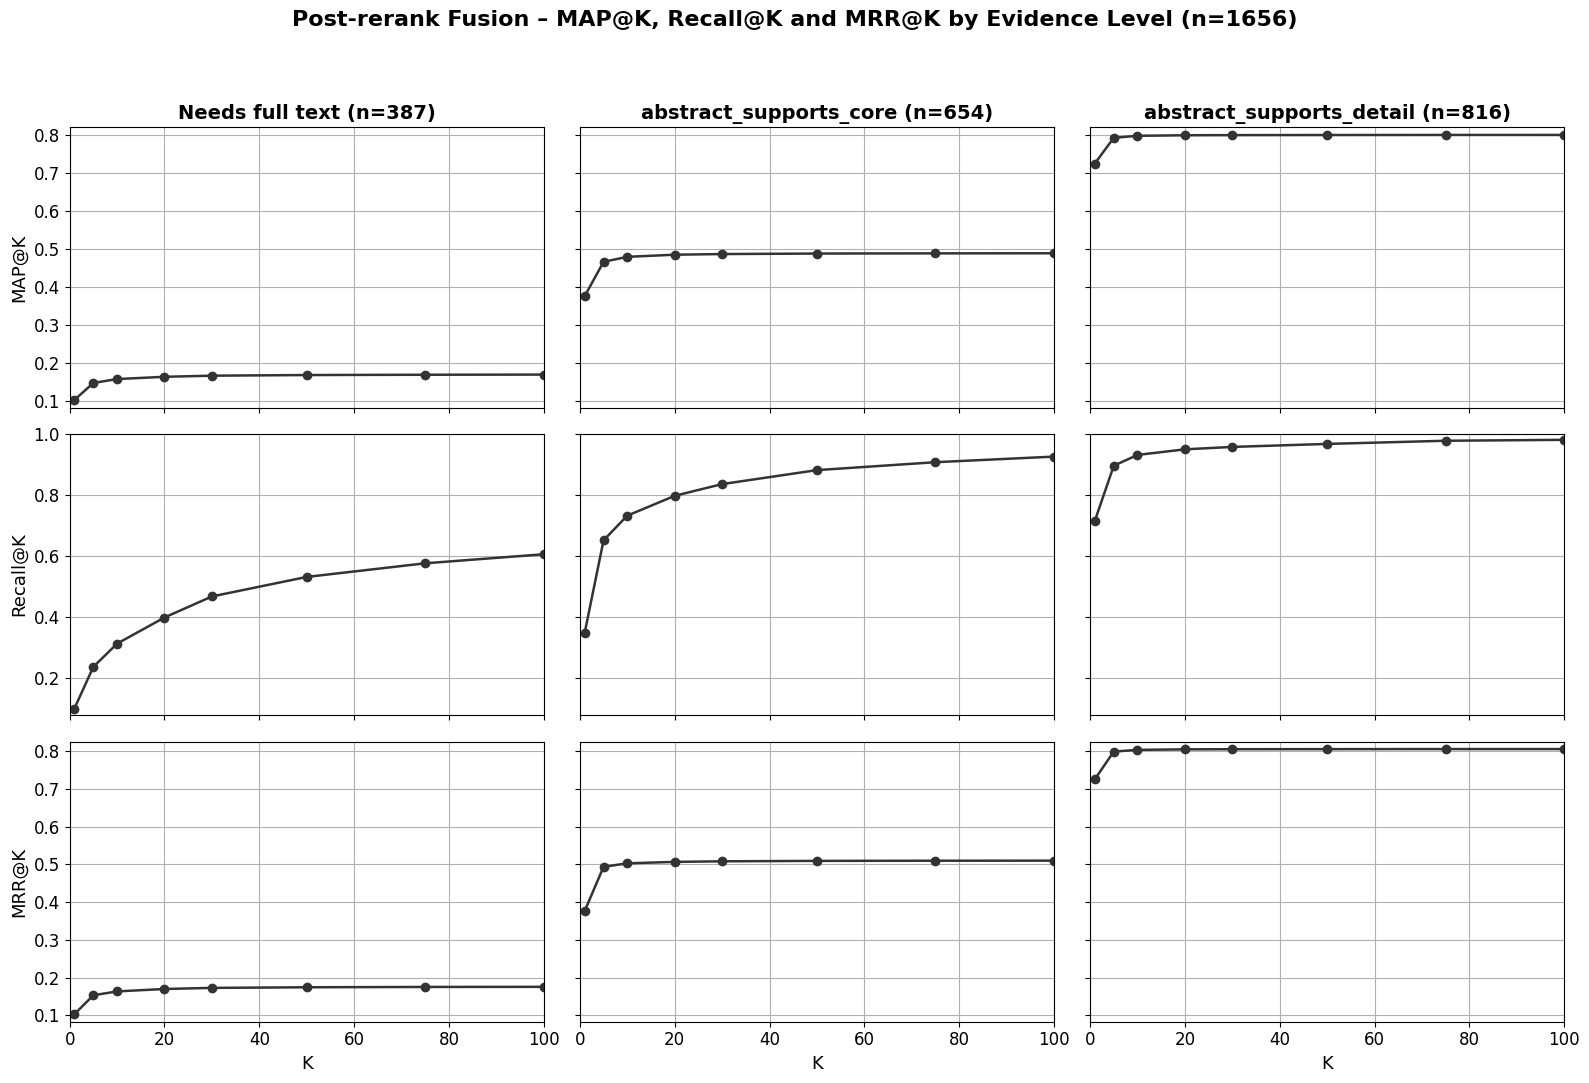

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/12b_post_rerank_fusion_recall_mrr_by_evidence_level_7a full public.png


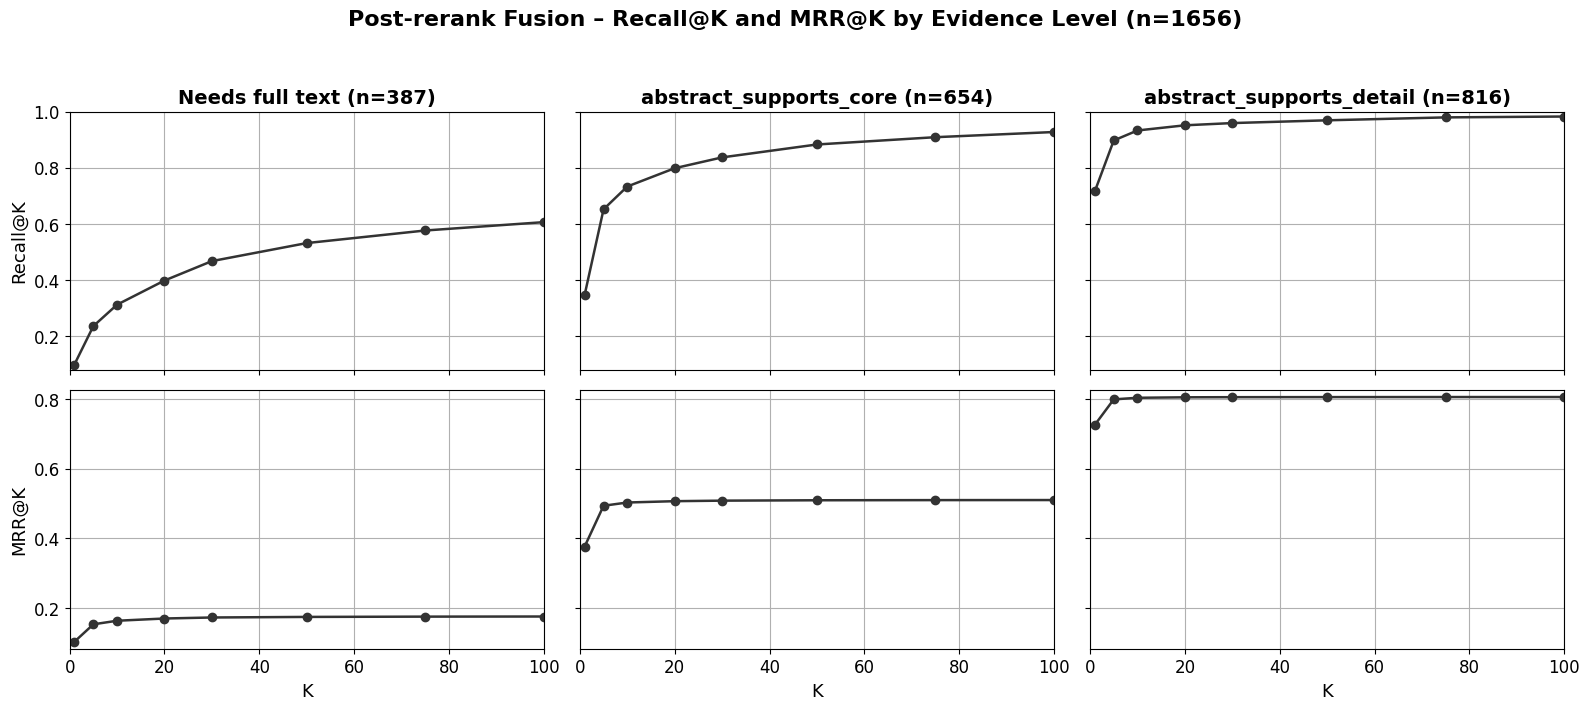

In [13]:
EVIDENCE_LEVEL_ORDER = [
    "abstract_support_details",
    "supports_core",
    "needs_fulltext",
]

EVIDENCE_LEVEL_LABELS = {
    "abstract_support_details": "Abstract support details",
    "supports_core": "Supports core",
    "needs_fulltext": "Needs full text",
}

ks_evidence = [1, 5, 10, 20, 30,  50, 75, 100]

# Single color for evidence-level curves (rows differ by metric label, not hue).
EVIDENCE_CURVE_COLOR = "#333333"


def _load_qrels_by_evidence_level(gold_jsonl: Path) -> dict[str, dict[str, set[str]]]:
    """Return {evidence_level: {qid: {pmid, ...}}} where each pmid belongs only to
    the level assigned to it in the docs list.  A single qid can appear in multiple
    levels if its gold docs carry different evidence labels.
    """
    level_qrels: dict[str, dict[str, set[str]]] = {}
    with gold_jsonl.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            for doc in (q.get("docs") or []):
                level = (doc.get("evidence_level") or "unknown").strip() or "unknown"
                pmid = str(doc.get("pmid") or "")
                if pmid:
                    level_qrels.setdefault(level, {}).setdefault(qid, set()).add(pmid)
    return level_qrels


for split in splits:
    print(f"Building evidence-level curves for split={split} ...")
    if not qrels_by_split.get(split):
        print("  No qrels for this split; skipping.")
        continue

    # Per-level filtered qrels: {level: {qid: {pmids with that level}}}
    level_qrels = _load_qrels_by_evidence_level(qrels_paths[split])

    fusion_runs_dir = rerank_dir / "post_rerank_fusion_snippet" / "runs"
    fusion_candidates = list(
        fusion_runs_dir.glob(f"best_rrf_{split}_top5000_rrf_poolR200_poolH200_k60.tsv")
    )
    if not fusion_candidates:
        print("  No post-rerank fusion run found; skipping.")
        continue
    fusion_run_df = _load_run(fusion_candidates[0])
    qid_col, doc_col = fusion_run_df.columns.tolist()

    run_docs: dict[str, list[str]] = {}
    for qid, group in fusion_run_df.groupby(qid_col, sort=False):
        run_docs[str(qid)] = group[doc_col].tolist()

    levels_present = sorted({lvl for lvl, lvl_q in level_qrels.items() if any(q in run_docs for q in lvl_q)})
    levels = [lvl for lvl in EVIDENCE_LEVEL_ORDER if lvl in levels_present]
    levels += [lvl for lvl in levels_present if lvl not in levels]
    if not levels:
        print("  No overlapping qids with evidence_level; skipping.")
        continue

    map_by_level: dict[str, list[float]] = {lvl: [] for lvl in levels}
    rec_by_level: dict[str, list[float]] = {lvl: [] for lvl in levels}
    mrr_by_level: dict[str, list[float]] = {lvl: [] for lvl in levels}
    n_by_level: dict[str, int] = {lvl: 0 for lvl in levels}

    for lvl in levels:
        # qrels filtered to only the pmids carrying this evidence level
        lvl_qrels = level_qrels.get(lvl, {})
        qids_lvl = [qid for qid in lvl_qrels if qid in run_docs]
        if not qids_lvl:
            map_by_level[lvl] = [0.0] * len(ks_evidence)
            rec_by_level[lvl] = [0.0] * len(ks_evidence)
            mrr_by_level[lvl] = [0.0] * len(ks_evidence)
            continue
        n_by_level[lvl] = len(qids_lvl)
        map_vals: list[float] = []
        rec_vals: list[float] = []
        mrr_vals: list[float] = []
        for k in ks_evidence:
            ap_scores: list[float] = []
            rec_scores: list[float] = []
            mrr_scores: list[float] = []
            for qid in qids_lvl:
                rels_set = lvl_qrels[qid]   # only pmids with this level
                if not rels_set:
                    continue
                docs = run_docs[qid]
                ap_scores.append(_ap_at_k(docs, rels_set, k))
                rec_scores.append(_recall_at_k(docs, rels_set, k))
                mrr_scores.append(_mrr_at_k(docs, rels_set, k))
            map_vals.append(float(np.mean(ap_scores)) if ap_scores else 0.0)
            rec_vals.append(float(np.mean(rec_scores)) if rec_scores else 0.0)
            mrr_vals.append(float(np.mean(mrr_scores)) if mrr_scores else 0.0)
        map_by_level[lvl] = map_vals
        rec_by_level[lvl] = rec_vals
        mrr_by_level[lvl] = mrr_vals

    all_map_vals = [v for vals in map_by_level.values() for v in vals]
    all_rec_vals = [v for vals in rec_by_level.values() for v in vals]
    all_mrr_vals = [v for vals in mrr_by_level.values() for v in vals]
    y_min_m = max(0.0, min(all_map_vals) - 0.02) if all_map_vals else 0.0
    y_max_m = min(1.0, max(all_map_vals) + 0.02) if all_map_vals else 1.0
    y_min_r = max(0.0, min(all_rec_vals) - 0.02) if all_rec_vals else 0.0
    y_max_r = min(1.0, max(all_rec_vals) + 0.02) if all_rec_vals else 1.0
    y_min_mrr = max(0.0, min(all_mrr_vals) - 0.02) if all_mrr_vals else 0.0
    y_max_mrr = min(1.0, max(all_mrr_vals) + 0.02) if all_mrr_vals else 1.0

    fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)
    axes_flat = axes.flatten()

    for idx, lvl in enumerate(levels):
        col_title = EVIDENCE_LEVEL_LABELS.get(lvl, lvl)
        n_q = n_by_level.get(lvl, 0)

        ax_map = axes_flat[idx]
        ax_map.plot(
            ks_evidence, map_by_level[lvl], marker="o", color=EVIDENCE_CURVE_COLOR, linewidth=1.8
        )
        ax_map.set_title(f"{col_title} (n={n_q})", fontweight="bold")
        ax_map.set_ylim(y_min_m, y_max_m)
        ax_map.set_ylabel("MAP@K" if idx == 0 else "")
        if idx != 0:
            ax_map.tick_params(axis="y", labelleft=False)
        ax_map.grid(True, axis="y")
        ax_map.grid(True, axis="x")

        ax_rec = axes_flat[idx + 3]
        ax_rec.plot(
            ks_evidence, rec_by_level[lvl], marker="o", color=EVIDENCE_CURVE_COLOR, linewidth=1.8
        )
        ax_rec.set_ylim(y_min_r, y_max_r)
        ax_rec.set_ylabel("Recall@K" if idx == 0 else "")
        if idx != 0:
            ax_rec.tick_params(axis="y", labelleft=False)
        ax_rec.grid(True, axis="y")
        ax_rec.grid(True, axis="x")

        ax_mrr = axes_flat[idx + 6]
        ax_mrr.plot(
            ks_evidence, mrr_by_level[lvl], marker="o", color=EVIDENCE_CURVE_COLOR, linewidth=1.8
        )
        ax_mrr.set_ylim(y_min_mrr, y_max_mrr)
        ax_mrr.set_ylabel("MRR@K" if idx == 0 else "")
        if idx != 0:
            ax_mrr.tick_params(axis="y", labelleft=False)
        ax_mrr.set_xlabel("K")
        ax_mrr.grid(True, axis="y")
        ax_mrr.grid(True, axis="x")

    for j in range(len(levels), 3):
        axes_flat[j].set_visible(False)
        axes_flat[j + 3].set_visible(False)
        axes_flat[j + 6].set_visible(False)

    for ax in axes_flat:
        ax.set_xlim(0, 100)

    fig.suptitle(
        _suptitle_n("Post-rerank Fusion – MAP@K, Recall@K and MRR@K by Evidence Level"),
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )
    _ev_rect = [0, 0, 1, 0.94] if _N_SPLIT_COLS <= 1 else [0, 0, 1, 0.96]
    plt.tight_layout(rect=_ev_rect)
    fig_path = (
        output_dir
        / f"12_post_rerank_fusion_map_recall_mrr_by_evidence_level_{split_labels.get(split, split)}.png"
    )
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

    # Recall + MRR only (same layout width, two metric rows).
    fig_b, axes_b = plt.subplots(2, 3, figsize=(16, 7.2), sharex=True)
    axes_b_flat = axes_b.flatten()

    for idx, lvl in enumerate(levels):
        col_title = EVIDENCE_LEVEL_LABELS.get(lvl, lvl)
        n_q = n_by_level.get(lvl, 0)

        ax_r = axes_b_flat[idx]
        ax_r.plot(
            ks_evidence, rec_by_level[lvl], marker="o", color=EVIDENCE_CURVE_COLOR, linewidth=1.8
        )
        ax_r.set_title(f"{col_title} (n={n_q})", fontweight="bold")
        ax_r.set_ylim(y_min_r, y_max_r)
        ax_r.set_ylabel("Recall@K" if idx == 0 else "")
        if idx != 0:
            ax_r.tick_params(axis="y", labelleft=False)
        ax_r.grid(True, axis="y")
        ax_r.grid(True, axis="x")

        ax_mm = axes_b_flat[idx + 3]
        ax_mm.plot(
            ks_evidence, mrr_by_level[lvl], marker="o", color=EVIDENCE_CURVE_COLOR, linewidth=1.8
        )
        ax_mm.set_ylim(y_min_mrr, y_max_mrr)
        ax_mm.set_ylabel("MRR@K" if idx == 0 else "")
        if idx != 0:
            ax_mm.tick_params(axis="y", labelleft=False)
        ax_mm.set_xlabel("K")
        ax_mm.grid(True, axis="y")
        ax_mm.grid(True, axis="x")

    for j in range(len(levels), 3):
        axes_b_flat[j].set_visible(False)
        axes_b_flat[j + 3].set_visible(False)

    for ax in axes_b_flat:
        ax.set_xlim(0, 100)

    fig_b.suptitle(
        _suptitle_n("Post-rerank Fusion – Recall@K and MRR@K by Evidence Level"),
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )
    plt.tight_layout(rect=_ev_rect)
    fig_path_b = (
        output_dir
        / f"12b_post_rerank_fusion_recall_mrr_by_evidence_level_{split_labels.get(split, split)}.png"
    )
    plt.savefig(fig_path_b, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path_b)
    plt.show()

## 13. Fig 3 Candidate — Main Paper

*Paper role:* main-paper Fig 3. Single-panel overlay of MRR@K curves for
each evidence level, paying off the §3.2 QE story by showing where current
methods still fail (`needs_fulltext` queries) and motivating the PDF-chunk
extension as future work.

Single-panel design (vs Fig S4's 3×3 grid) chosen to make the gap between
`needs_fulltext` and the abstract-resolvable levels visible at a glance.
Uses MRR@K (not Recall@K) because qrels are document-level — the same PMIDs
would be retrieved across evidence levels; what differs is whether the
abstract surfaces the claim well enough to rank highly.

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/fig3_candidate_evidence_level_mrr.png


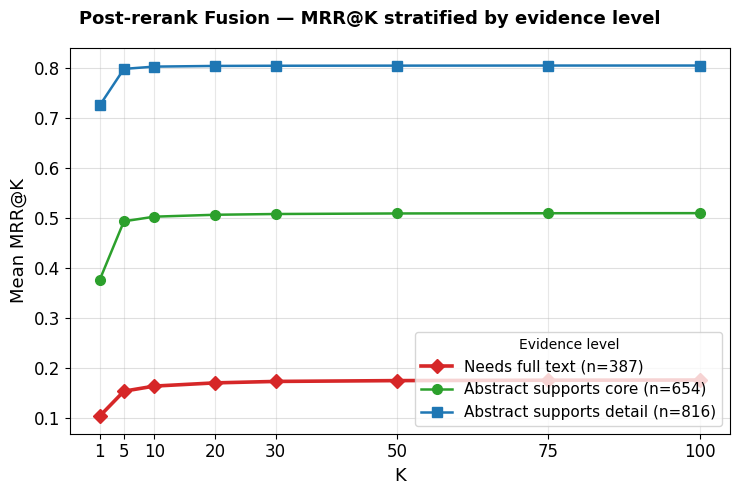


MRR@10 by evidence level:
  Needs full text            n= 387  MRR@10=0.1636
  Abstract supports core     n= 654  MRR@10=0.5028
  Abstract supports detail   n= 816  MRR@10=0.8033

Recall@100 by evidence level (to argue 'same docs retrieved, different surfacing'):
  Needs full text            n= 387  Recall@100=0.6064
  Abstract supports core     n= 654  Recall@100=0.9271
  Abstract supports detail   n= 816  Recall@100=0.9822


In [14]:
# Reuse mrr_by_level / n_by_level / levels / ks_evidence from Section 12 above.
EVIDENCE_FIG3_COLORS = {
    "abstract_supports_core":     "#2ca02c",  # green — abstract sufficient, best
    "abstract_supports_detail":   "#1f77b4",  # blue — abstract sufficient, secondary
    "needs_fulltext":             "#d62728",  # red — abstract insufficient, the ceiling
}
EVIDENCE_FIG3_MARKERS = {
    "abstract_supports_core":     "o",
    "abstract_supports_detail":   "s",
    "needs_fulltext":             "D",
}
EVIDENCE_FIG3_LW = {
    "abstract_supports_core":     1.8,
    "abstract_supports_detail":   1.8,
    "needs_fulltext":             2.6,  # bold the focal level
}
# Fig-3-specific pretty labels (Section 12's EVIDENCE_LEVEL_LABELS dict uses
# different keys than the data, leaving most levels unlabeled; override here).
EVIDENCE_FIG3_LABELS = {
    "abstract_supports_core":     "Abstract supports core",
    "abstract_supports_detail":   "Abstract supports detail",
    "needs_fulltext":             "Needs full text",
}

# Compact x-axis: K up to 100 (where the message lives — top-of-list quality)
fig3_ks = [k for k in ks_evidence if k <= 100]
fig3_ks_idx = [ks_evidence.index(k) for k in fig3_ks]

fig3, ax3 = plt.subplots(figsize=(7.5, 5))

for lvl in levels:
    if lvl not in mrr_by_level:
        continue
    color = EVIDENCE_FIG3_COLORS.get(lvl, "#888888")
    marker = EVIDENCE_FIG3_MARKERS.get(lvl, "o")
    lw = EVIDENCE_FIG3_LW.get(lvl, 1.8)
    label = f"{EVIDENCE_FIG3_LABELS.get(lvl, lvl)} (n={n_by_level.get(lvl, 0)})"
    vals = [mrr_by_level[lvl][i] for i in fig3_ks_idx]
    ax3.plot(
        fig3_ks, vals,
        marker=marker, markersize=7, linewidth=lw,
        color=color, label=label,
    )

ax3.set_xlabel("K")
ax3.set_ylabel("Mean MRR@K")
ax3.set_xticks(fig3_ks)
ax3.set_xticklabels([str(k) for k in fig3_ks])
ax3.grid(True, axis="y", alpha=0.4)
ax3.grid(True, axis="x", alpha=0.3)
ax3.legend(fontsize=11, loc="lower right", title="Evidence level")
fig3.suptitle(
    f"Post-rerank Fusion — MRR@K stratified by evidence level",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
fig3_path = output_dir / "fig3_candidate_evidence_level_mrr.png"
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
print("Saved:", fig3_path)
plt.show()

# Numbers for §3.3
print("\nMRR@10 by evidence level:")
for lvl in levels:
    if lvl in mrr_by_level and 10 in ks_evidence:
        v = mrr_by_level[lvl][ks_evidence.index(10)]
        n = n_by_level.get(lvl, 0)
        print(f"  {EVIDENCE_FIG3_LABELS.get(lvl, lvl):26s} n={n:4d}  MRR@10={v:.4f}")

print("\nRecall@100 by evidence level (to argue 'same docs retrieved, different surfacing'):")
for lvl in levels:
    if lvl in rec_by_level and 100 in ks_evidence:
        v = rec_by_level[lvl][ks_evidence.index(100)]
        n = n_by_level.get(lvl, 0)
        print(f"  {EVIDENCE_FIG3_LABELS.get(lvl, lvl):26s} n={n:4d}  Recall@100={v:.4f}")

## 14. Draft Results Text — §3.3 Where current methods still fail

*Numbers populated from the cell above. Goldset n=1,656 (same as §3.1);
subset counts per evidence level appear in the figure legend.*

> **3.3 Claims supported only in full text are not recoverable from
> abstracts.** Each citation context in our goldset is annotated with one
> of three evidence levels reflecting how the cited paper supports the
> claim: `abstract_supports_core` (the abstract states the claim's core
> finding), `abstract_supports_detail` (the abstract contains supporting
> detail for the claim), and `needs_fulltext` (the supporting passage
> appears only in the body of the paper). Stratifying our best pipeline
> configuration (Post-rerank Fusion) by evidence level reveals a sharp
> divide (**Fig 3**): on the abstract-resolvable levels, MRR@10 reaches
> 0.80 (`abstract_supports_detail`, n=816) and 0.50
> (`abstract_supports_core`, n=654), with Recall@100 above 0.92 in both
> cases. On `needs_fulltext` queries (n=387), MRR@10 collapses to 0.16
> and — critically — Recall@100 drops to 0.61. The deficit is therefore
> not merely a ranking issue: roughly 40% of these queries fail to
> retrieve the gold paper anywhere in the top-100, indicating that the
> abstract content is too misaligned with the claim wording to surface
> the relevant document. Improving these queries thus requires content
> beyond the abstract; we describe ongoing work on full-text passage
> indexing in §5.

**Notes for the discussion:**

- `abstract_supports_detail` outperforms `abstract_supports_core` (0.80
  vs 0.50 MRR@10), which is initially counterintuitive. A plausible
  reading: "detail" claims (e.g., specific gene names, measurements,
  phenotype phrases) carry highly specific terminology that matches the
  abstract verbatim, whereas "core" claims paraphrase the paper's main
  finding with looser lexical overlap. This reinforces §3.1's
  lexical-dominance theme but is a sidebar — keep brief or move to
  discussion if space is tight.
- The Recall@100 deficit on `needs_fulltext` is the strongest single
  piece of evidence motivating full-text indexing. Worth including in
  the abstract / contributions list.